# Step 1: Configure Pipeline

In [3]:
import os
import re
import json
import argparse
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import rasterio


# Step 2: Apply QC, Cloud, and Water Masking

In [4]:
# ================== Filename parsing (unchanged from notebook) ==================

FILENAME_PATTERN = re.compile(
    r'^ECO_L2T_LSTE\.(?P<version>\d{3})_'
    r'(?P<band>LST_err|LST|QC|cloud|water|height|EmisWB)_'
    r'(?P<timestamp>\d{8}T\d{6})_'
    r'aid(?P<aid>\d+)_'
    r'(?P<utm_zone>\d{1,2}[A-Z])'
    r'\.tiff?$',
    re.IGNORECASE
)


def list_tiffs(folder_path):
    if not os.path.isdir(folder_path):
        return []
    return [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if os.path.isfile(os.path.join(folder_path, f)) and f.lower().endswith((".tif", ".tiff"))
    ]


def parse_ecostress_filename(path):
    filename = os.path.basename(path)
    match = FILENAME_PATTERN.match(filename)
    if not match:
        print(f"  Skipping (doesn't match expected pattern): {filename}")
        return None

    try:
        dt_utc = datetime.strptime(match.group("timestamp"), "%Y%m%dT%H%M%S").replace(
            tzinfo=ZoneInfo("UTC")
        )
    except ValueError:
        print(f"  Skipping (bad timestamp): {filename}")
        return None

    return {
        "version": match.group("version"),
        "band": match.group("band"),
        "dt_utc": dt_utc,
        "aid": match.group("aid"),
        "utm_zone": match.group("utm_zone"),
        "path": path,
    }


def group_files_by_acquisition(folder_path):
    """Returns {(timestamp_str, aid, utm_zone): {band_name: filepath, ...}}"""
    groups = {}
    for fpath in list_tiffs(folder_path):
        parsed = parse_ecostress_filename(fpath)
        if parsed is None:
            continue
        key = (parsed["dt_utc"].strftime("%Y%m%dT%H%M%S"), parsed["aid"], parsed["utm_zone"])
        groups.setdefault(key, {})[parsed["band"]] = fpath
    return groups


# ================== QC lookup ==================

def load_acceptable_qc_values(qc_lookup_path, require_produced_by_tes,
                               acceptable_data_quality_flags,
                               acceptable_lst_accuracy_labels):
    if not os.path.isfile(qc_lookup_path):
        raise FileNotFoundError(
            f"QC lookup CSV not found: {qc_lookup_path}\n"
            f"Make sure {os.path.basename(qc_lookup_path)} is in the expected location."
        )

    qc_lookup = pd.read_csv(qc_lookup_path)
    mask = pd.Series(True, index=qc_lookup.index)

    if require_produced_by_tes:
        mask &= qc_lookup["Mandatory QA flags"].str.startswith(
            "Pixel produced by TES", na=False
        )

    mask &= qc_lookup["Data quality flag"].isin(acceptable_data_quality_flags)
    mask &= qc_lookup["LST accuracy"].isin(acceptable_lst_accuracy_labels)

    acceptable_values = set(qc_lookup.loc[mask, "Value"].astype(int))
    print(
        f"Loaded QC lookup: {len(qc_lookup)} total QC values, "
        f"{len(acceptable_values)} acceptable QC values selected."
    )
    return acceptable_values


# ================== Masking ==================

def apply_qc_mask(band_files, acceptable_qc_values, mask_clouds, mask_water,
                   cloud_flag_value, water_flag_value, out_path, min_valid_ratio):
    if "LST" not in band_files or "QC" not in band_files:
        return {
            "n_tile_pixels": 0, "n_footprint": 0, "n_valid": 0,
            "valid_ratio": None, "passed_threshold": False, "written": False,
        }

    with rasterio.open(band_files["LST"]) as lst_src:
        lst = lst_src.read(1).astype("float32")
        if lst_src.nodata is not None and not np.isnan(lst_src.nodata):
            lst = np.where(lst == lst_src.nodata, np.nan, lst)
        meta = lst_src.meta.copy()

    with rasterio.open(band_files["QC"]) as qc_src:
        qc = qc_src.read(1)

    footprint_mask = np.isfinite(lst)
    n_tile_pixels = int(lst.size)
    n_footprint = int(footprint_mask.sum())

    good_mask = footprint_mask & np.isin(qc, list(acceptable_qc_values))

    if mask_clouds and "cloud" in band_files:
        with rasterio.open(band_files["cloud"]) as cloud_src:
            cloud = cloud_src.read(1)
        good_mask &= (cloud == cloud_flag_value)

    if mask_water and "water" in band_files:
        with rasterio.open(band_files["water"]) as water_src:
            water = water_src.read(1)
        good_mask &= (water == water_flag_value)

    lst_masked = np.where(good_mask, lst, np.nan)
    n_valid = int(np.isfinite(lst_masked).sum())
    valid_ratio = (n_valid / n_footprint) if n_footprint else 0.0
    passed = valid_ratio >= min_valid_ratio

    result = {
        "n_tile_pixels": n_tile_pixels, "n_footprint": n_footprint,
        "n_valid": n_valid, "valid_ratio": valid_ratio,
        "passed_threshold": passed, "written": False,
    }

    if not passed:
        return result

    meta.update({"dtype": "float32", "nodata": np.nan})
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(lst_masked, 1)

    result["written"] = True
    return result


# ================== Step orchestration ==================

def run_step2_masking(config):
    input_folder = config["input_folder"]
    qc_cfg = config["qc_masking"]
    valid_cfg = config["valid_pixel_filter"]
    out_cfg = config["output"]

    # root_dir: parent of input_folder unless explicitly overridden
    root_dir = out_cfg.get("root_dir") or os.path.dirname(os.path.normpath(input_folder))
    masked_tiff_dir = os.path.join(root_dir, out_cfg.get("masked_tiff_dirname", "02_masked_tiff"))
    os.makedirs(masked_tiff_dir, exist_ok=True)

    acceptable_qc_values = load_acceptable_qc_values(
        qc_cfg["qc_lookup_csv"],
        qc_cfg["require_produced_by_tes"],
        qc_cfg["acceptable_data_quality_flags"],
        qc_cfg["acceptable_lst_accuracy_labels"],
    )

    print(f"Scanning {input_folder} ...")
    acquisitions = group_files_by_acquisition(input_folder)
    print(f"Found {len(acquisitions)} acquisition(s)")

    manifest_records = []
    n_written = 0

    for (ts, aid, utm_zone), band_files in sorted(acquisitions.items()):
        out_name = f"ECO_L2T_LSTE_{ts}_aid{aid}_{utm_zone}_LST_qcmasked.tif"
        out_path = os.path.join(masked_tiff_dir, out_name)

        result = apply_qc_mask(
            band_files,
            acceptable_qc_values,
            qc_cfg["mask_clouds"],
            qc_cfg["mask_water"],
            qc_cfg["cloud_flag_value"],
            qc_cfg["water_flag_value"],
            out_path,
            valid_cfg["min_valid_ratio"],
        )

        if result["written"]:
            n_written += 1

        manifest_records.append({
            "acquisition_id": f"{ts}_aid{aid}_{utm_zone}",
            "timestamp_utc": ts,
            "aid": aid,
            "utm_zone": utm_zone,
            "raw_band_paths": band_files,          # e.g. {"LST": "...", "QC": "...", "cloud": "..."}
            "masked_tiff_path": out_path if result["written"] else None,
            "n_tile_pixels": result["n_tile_pixels"],
            "n_footprint": result["n_footprint"],
            "n_valid": result["n_valid"],
            "valid_ratio": result["valid_ratio"],
            "passed_threshold": result["passed_threshold"],
            "written": result["written"],
        })

    manifest = {
        "step": "step2_masking",
        "generated_at": datetime.now(ZoneInfo("UTC")).isoformat(),
        "input_folder": input_folder,
        "masked_tiff_dir": masked_tiff_dir,
        "min_valid_ratio": valid_cfg["min_valid_ratio"],
        "n_acquisitions_scanned": len(manifest_records),
        "n_files_written": n_written,
        "acquisitions": manifest_records,
    }

    manifest_path = os.path.join(masked_tiff_dir, "step2_masking_manifest.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2, default=str)

    print("\n=== Step 2 Masking Summary ===")
    print(f"Acquisitions scanned : {len(manifest_records)}")
    print(f"Files written        : {n_written}")
    print(f"Masked tiff dir      : {masked_tiff_dir}")
    print(f"Manifest saved       : {manifest_path}")

    return manifest


CONFIG_PATH = "config.json"

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

manifest = run_step2_masking(config)

Loaded QC lookup: 209 total QC values, 66 acceptable QC values selected.
Scanning /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/LA_Tiffs ...
Found 2241 acquisition(s)

=== Step 2 Masking Summary ===
Acquisitions scanned : 2241
Files written        : 451
Masked tiff dir      : /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff
Manifest saved       : /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/step2_masking_manifest.json


# Step 3: Organize Masked TIFFs by Local Hour

Loaded Step 2 manifest -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/step2_masking_manifest.json
Acquisitions in manifest: 2241

Skipped (not written / didn't pass threshold): 1790
Skipped (bad timestamp): 0
Hour 00:00 -> 13 file(s)
Hour 01:00 -> 21 file(s)
Hour 02:00 -> 18 file(s)
Hour 03:00 -> 8 file(s)
Hour 04:00 -> 16 file(s)
Hour 05:00 -> 17 file(s)
Hour 06:00 -> 16 file(s)
Hour 07:00 -> 17 file(s)
Hour 08:00 -> 20 file(s)
Hour 09:00 -> 18 file(s)
Hour 10:00 -> 31 file(s)
Hour 11:00 -> 19 file(s)
Hour 12:00 -> 20 file(s)
Hour 13:00 -> 27 file(s)
Hour 14:00 -> 31 file(s)
Hour 15:00 -> 26 file(s)
Hour 16:00 -> 19 file(s)
Hour 17:00 -> 18 file(s)
Hour 18:00 -> 12 file(s)
Hour 19:00 -> 12 file(s)
Hour 20:00 -> 18 file(s)
Hour 21:00 -> 14 file(s)
Hour 22:00 -> 19 file(s)
Hour 23:00 -> 21 file(s)


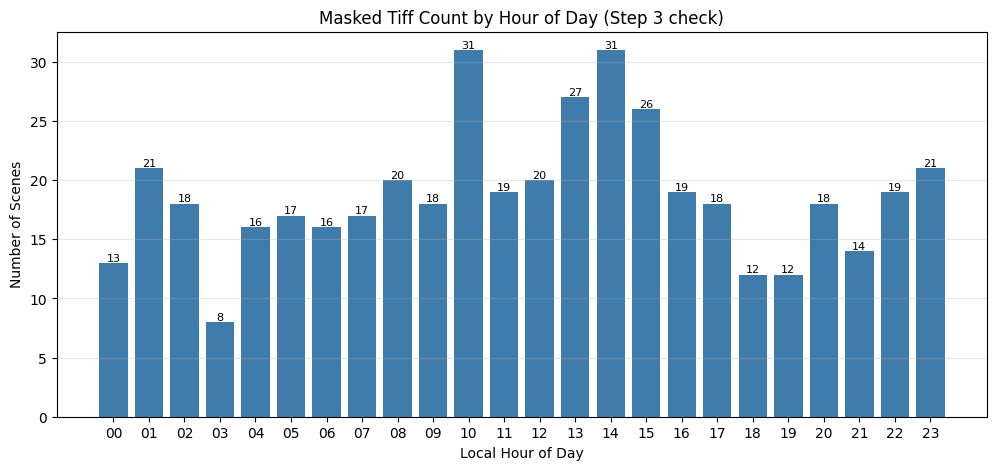


Step 3 manifest saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/step3_hour_organization_manifest.json
Total files organized: 451


In [5]:

import os
import json
from datetime import datetime
from zoneinfo import ZoneInfo


## Load config + Step 2 manifest

CONFIG_PATH = "config.json"  # path to the Step 1 pipeline config JSON

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

temporal_cfg = config["temporal_organization"]
out_cfg = config["output"]

LOCAL_TZ = temporal_cfg["local_timezone"]
SEASON_MONTHS = temporal_cfg["season_months"]

# Resolve root_dir the same way Step 2 did
input_folder = config["input_folder"]
root_dir = out_cfg.get("root_dir") or os.path.dirname(os.path.normpath(input_folder))
masked_tiff_dir = os.path.join(root_dir, out_cfg.get("masked_tiff_dirname", "masked_tiff"))

step2_manifest_path = os.path.join(masked_tiff_dir, "step2_masking_manifest.json")

with open(step2_manifest_path, "r") as f:
    step2_manifest = json.load(f)

print(f"Loaded Step 2 manifest -> {step2_manifest_path}")
print(f"Acquisitions in manifest: {len(step2_manifest['acquisitions'])}")

## Parsing + season classification helpers

HOUR_LABELS = [f"{h:02d}" for h in range(24)]


def classify_season(month, season_months = SEASON_MONTHS):
    for season, months in season_months.items():
        if month in months:
            return season
    return "Unknown"


def parse_timestamp_utc(ts_str):
    """ts_str like '20180802T230140' -> tz-aware UTC datetime."""
    return datetime.strptime(ts_str, "%Y%m%dT%H%M%S").replace(tzinfo = ZoneInfo("UTC"))


## Bin masked tiffs by local hour of day

def organize_by_hour(step2_manifest, local_tz = LOCAL_TZ):
    """
    Reads acquisitions from the Step 2 manifest (only those that were
    actually written -- i.e. passed QC + valid-ratio threshold), and buckets
    them into 24 hour-of-day arrays based on local acquisition time.

    Returns: dict with keys "00".."23", each a list of entry dicts.
    """
    hour_bins = {h: [] for h in HOUR_LABELS}

    n_skipped_not_written = 0
    n_skipped_bad_ts = 0

    for acq in step2_manifest["acquisitions"]:
        if not acq.get("written") or not acq.get("masked_tiff_path"):
            n_skipped_not_written += 1
            continue

        try:
            dt_utc = parse_timestamp_utc(acq["timestamp_utc"])
        except (ValueError, KeyError):
            print(f"  Skipping (bad/missing timestamp): {acq.get('acquisition_id')}")
            n_skipped_bad_ts += 1
            continue

        dt_local = dt_utc.astimezone(ZoneInfo(local_tz))
        hour_label = f"{dt_local.hour:02d}"
        season = classify_season(dt_local.month)

        entry = {
            "acquisition_id": acq["acquisition_id"],
            "masked_tiff_path": acq["masked_tiff_path"],
            "timestamp_utc": acq["timestamp_utc"],
            "datetime_local": dt_local.isoformat(),
            "season": season,
        }

        hour_bins[hour_label].append(entry)

    print(f"\nSkipped (not written / didn't pass threshold): {n_skipped_not_written}")
    print(f"Skipped (bad timestamp): {n_skipped_bad_ts}")

    return hour_bins


hour_bins = organize_by_hour(step2_manifest)

for h in HOUR_LABELS:
    n = len(hour_bins[h])
    if n:
        print(f"Hour {h}:00 -> {n} file(s)")

## Quick diurnal distribution check

import matplotlib.pyplot as plt


counts = [len(hour_bins[h]) for h in HOUR_LABELS]

fig, ax = plt.subplots(figsize = (12, 5))
ax.bar(HOUR_LABELS, counts, color = "#3f7cac")
for i, count in enumerate(counts):
    if count:
        ax.text(i, count, str(count), ha = "center", va = "bottom", fontsize = 8)

ax.set_xlabel("Local Hour of Day")
ax.set_ylabel("Number of Scenes")
ax.set_title("Masked Tiff Count by Hour of Day (Step 3 check)")
ax.grid(True, axis = "y", alpha = 0.3)
plt.show()

## Write Step 3 manifest

manifest = {
    "step": "step3_hour_organization",
    "generated_at": datetime.now(ZoneInfo("UTC")).isoformat(),
    "masked_tiff_dir": masked_tiff_dir,
    "local_timezone": LOCAL_TZ,
    "n_total_files": sum(len(hour_bins[h]) for h in HOUR_LABELS),
    "hour_bins": hour_bins,  # keys "00".."23", each a list of entry dicts
}

step3_manifest_path = os.path.join(masked_tiff_dir, "step3_hour_organization_manifest.json")

with open(step3_manifest_path, "w") as f:
    json.dump(manifest, f, indent = 2, default = str)

print(f"\nStep 3 manifest saved -> {step3_manifest_path}")
print(f"Total files organized: {manifest['n_total_files']}")

# Step 4: Merge Same-Pass Scenes

In [6]:
import os
import json
import numpy as np
import rasterio
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from concurrent.futures import ThreadPoolExecutor, as_completed


## Load config + Step 3 manifest

CONFIG_PATH = "config.json"

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

temporal_cfg = config["temporal_organization"]
out_cfg = config["output"]
proc_cfg = config["processing"]

MERGE_WINDOW_MIN = temporal_cfg["merge_window_minutes"]
MERGE_MAX_WORKERS = proc_cfg.get("merge_max_workers", 4)

input_folder = config["input_folder"]
root_dir = out_cfg.get("root_dir") or os.path.dirname(os.path.normpath(input_folder))
masked_tiff_dir = os.path.join(root_dir, out_cfg.get("masked_tiff_dirname", "masked_tiff"))
merged_dir = os.path.join(masked_tiff_dir, out_cfg.get("merged_subdirname", "merged"))
os.makedirs(merged_dir, exist_ok = True)

step3_manifest_path = os.path.join(masked_tiff_dir, "step3_hour_organization_manifest.json")

with open(step3_manifest_path, "r") as f:
    step3_manifest = json.load(f)

hour_bins_in = step3_manifest["hour_bins"]
HOUR_LABELS = [f"{h:02d}" for h in range(24)]

print(f"Loaded Step 3 manifest -> {step3_manifest_path}")
print(f"Merge window: {MERGE_WINDOW_MIN} min | Max workers: {MERGE_MAX_WORKERS}")


## Grouping helper -- consecutive entries within the merge window

def group_by_time(entries, max_minutes):
    """
    entries: list of dicts with 'datetime_local' (ISO string).
    Returns a list of groups, where each group is a list of entries whose
    consecutive local timestamps are all within max_minutes of the previous one.
    """
    max_delta = timedelta(minutes = max_minutes)

    items = sorted(entries, key = lambda e: e["datetime_local"])

    groups = []
    current_group = []

    for entry in items:
        dt_local = datetime.fromisoformat(entry["datetime_local"])

        if not current_group:
            current_group = [entry]
            current_group_dts = [dt_local]
            continue

        prev_dt = current_group_dts[-1]
        if dt_local - prev_dt <= max_delta:
            current_group.append(entry)
            current_group_dts.append(dt_local)
        else:
            groups.append(current_group)
            current_group = [entry]
            current_group_dts = [dt_local]

    if current_group:
        groups.append(current_group)

    return groups


## Mosaic (mean-of-overlap) helper

def mosaic_mean(files, out_path):
    """Mosaic a list of GeoTIFFs using the mean for overlapping pixels."""
    from rasterio.warp import reproject, Resampling
    from rasterio.transform import from_bounds

    datasets = []

    for f in files:
        ds = rasterio.open(f)

        # Debug georeferencing issues
        if ds.crs is None or ds.transform == rasterio.Affine.identity():
            print("\n⚠️ WARNING: Missing georeferencing")
            print(f"File causing issue: {f}")
            print(f"CRS: {ds.crs}")
            print(f"Transform: {ds.transform}")
            print(f"Bounds: {ds.bounds}")
            print()

        datasets.append(ds)

    ref = datasets[0]
    ref_crs = ref.crs

    xres, yres = ref.res
    xres, yres = abs(xres), abs(yres)

    minxs, maxxs, minys, maxys = [], [], [], []
    for ds in datasets:
        if ds.crs != ref_crs:
            for d in datasets:
                d.close()
            raise ValueError(f"CRS mismatch while merging {files}")
        b = ds.bounds
        minxs.append(min(b.left, b.right))
        maxxs.append(max(b.left, b.right))
        minys.append(min(b.bottom, b.top))
        maxys.append(max(b.bottom, b.top))

    minx, maxx = min(minxs), max(maxxs)
    miny, maxy = min(minys), max(maxys)

    width = int(np.ceil((maxx - minx) / xres))
    height = int(np.ceil((maxy - miny) / yres))
    mosaic_transform = from_bounds(minx, miny, maxx, maxy, width, height)

    n = len(datasets)
    stack = np.full((n, height, width), np.nan, dtype = "float32")

    for i, ds in enumerate(datasets):
        data = ds.read(1).astype("float32")
        if ds.nodata is not None and not np.isnan(ds.nodata):
            data = np.where(data == ds.nodata, np.nan, data)

        dest = np.full((height, width), np.nan, dtype = "float32")


        reproject(
            source = data,
            destination = dest,
            src_transform = ds.transform,
            src_crs = ds.crs,
            dst_transform = mosaic_transform,
            dst_crs = ref_crs,
            src_nodata = None,
            dst_nodata = np.nan,
            resampling = Resampling.nearest,
        )
        stack[i] = dest

    mosaic_arr = np.nanmean(stack, axis = 0).astype("float32")

    meta = ref.meta.copy()
    meta.update({
        "height": height, "width": width, "transform": mosaic_transform,
        "dtype": "float32", "nodata": np.nan,
    })

    os.makedirs(os.path.dirname(out_path), exist_ok = True)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(mosaic_arr, 1)

    for ds in datasets:
        ds.close()


## Per-group worker -- returns the resulting manifest entry

def process_group(hour_label, group, merged_dir):
    """
    A 'group' of 1 entry passes through unchanged.
    A 'group' of 2+ entries gets mosaicked into one merged tiff.
    Returns a single manifest entry dict representing the group's output.
    """
    if len(group) == 1:
        entry = group[0]
        return {
            "tiff_path": entry["masked_tiff_path"],
            "is_merged": False,
            "source_acquisition_ids": [entry["acquisition_id"]],
            "season": entry["season"],
            "datetime_local": entry["datetime_local"],
        }

    # multiple entries -> mosaic
    group_files = [e["masked_tiff_path"] for e in group]
    dts_local = [datetime.fromisoformat(e["datetime_local"]) for e in group]
    first_dt, last_dt = min(dts_local), max(dts_local)

    ts1 = first_dt.strftime("%Y%m%dT%H%M%S")
    ts2 = last_dt.strftime("%Y%m%dT%H%M%S")

    hour_out_dir = os.path.join(merged_dir, f"Hour_{hour_label}")
    out_name = f"Hour{hour_label}_{ts1}_to_{ts2}_mean.tif"
    out_path = os.path.join(hour_out_dir, out_name)

    mosaic_mean(group_files, out_path)

    return {
        "tiff_path": out_path,
        "is_merged": True,
        "source_acquisition_ids": [e["acquisition_id"] for e in group],
        "season": group[0]["season"],  # same merge window -> same season virtually always
        "datetime_local": first_dt.isoformat(),
    }


## Run merge across all 24 hour bins (thread pool over merge groups)

def run_step4_merge(hour_bins_in, merge_window_min, merged_dir, max_workers):
    # First, build the full list of (hour_label, group) jobs across all hours
    jobs = []
    for h in HOUR_LABELS:
        entries = hour_bins_in.get(h, [])
        if not entries:
            continue
        groups = group_by_time(entries, max_minutes = merge_window_min)
        for group in groups:
            jobs.append((h, group))

    print(f"Total merge groups to process: {len(jobs)} (across {len(HOUR_LABELS)} hour bins)")

    hour_bins_out = {h: [] for h in HOUR_LABELS}
    n_merged_groups = 0
    n_passthrough = 0
    errors = []

    with ThreadPoolExecutor(max_workers = max_workers) as executor:
        future_to_job = {
            executor.submit(process_group, h, group, merged_dir): (h, group)
            for h, group in jobs
        }

        for future in as_completed(future_to_job):
            h, group = future_to_job[future]
            try:
                result_entry = future.result()
                hour_bins_out[h].append(result_entry)
                if result_entry["is_merged"]:
                    n_merged_groups += 1
                else:
                    n_passthrough += 1
            except Exception as e:
                errors.append({
                    "hour": h,
                    "acquisition_ids": [e2["acquisition_id"] for e2 in group],
                    "error": str(e),
                })
                print(f"  [Hour {h}] ERROR merging group: {e}")

    # sort each hour bin's entries chronologically for readability
    for h in HOUR_LABELS:
        hour_bins_out[h].sort(key = lambda e: e["datetime_local"])

    print("\n=== Step 4 Merge Summary ===")
    print(f"Merged groups (2+ scenes) : {n_merged_groups}")
    print(f"Passthrough (single scene): {n_passthrough}")
    print(f"Errors                    : {len(errors)}")

    return hour_bins_out, errors


hour_bins_out, merge_errors = run_step4_merge(
    hour_bins_in, MERGE_WINDOW_MIN, merged_dir, MERGE_MAX_WORKERS
)

for h in HOUR_LABELS:
    n = len(hour_bins_out[h])
    if n:
        print(f"Hour {h}:00 -> {n} tiff(s) after merge")

## Write Step 4 manifest

manifest = {
    "step": "step4_merge",
    "generated_at": datetime.now(ZoneInfo("UTC")).isoformat(),
    "masked_tiff_dir": masked_tiff_dir,
    "merged_dir": merged_dir,
    "merge_window_minutes": MERGE_WINDOW_MIN,
    "n_total_tiffs": sum(len(hour_bins_out[h]) for h in HOUR_LABELS),
    "n_errors": len(merge_errors),
    "errors": merge_errors,
    "hour_bins": hour_bins_out,  # keys "00".."23", each entry either merged or passthrough
}

step4_manifest_path = os.path.join(masked_tiff_dir, "step4_merge_manifest.json")

with open(step4_manifest_path, "w") as f:
    json.dump(manifest, f, indent = 2, default = str)

print(f"\nStep 4 manifest saved -> {step4_manifest_path}")
print(f"Total tiffs after merge: {manifest['n_total_tiffs']}")
if merge_errors:
    print(f"WARNING: {len(merge_errors)} group(s) failed to merge -- see 'errors' in manifest.")

Loaded Step 3 manifest -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/step3_hour_organization_manifest.json
Merge window: 2 min | Max workers: 4
Total merge groups to process: 400 (across 24 hour bins)

=== Step 4 Merge Summary ===
Merged groups (2+ scenes) : 51
Passthrough (single scene): 349
Errors                    : 0
Hour 00:00 -> 12 tiff(s) after merge
Hour 01:00 -> 20 tiff(s) after merge
Hour 02:00 -> 15 tiff(s) after merge
Hour 03:00 -> 7 tiff(s) after merge
Hour 04:00 -> 16 tiff(s) after merge
Hour 05:00 -> 14 tiff(s) after merge
Hour 06:00 -> 12 tiff(s) after merge
Hour 07:00 -> 16 tiff(s) after merge
Hour 08:00 -> 19 tiff(s) after merge
Hour 09:00 -> 15 tiff(s) after merge
Hour 10:00 -> 24 tiff(s) after merge
Hour 11:00 -> 17 tiff(s) after merge
Hour 12:00 -> 17 tiff(s) after merge
Hour 13:00 -> 24 tiff(s) after merge
Hour 14:00 -> 26 tiff(s) after merge
Hour 15:00 -> 22 tiff(s) after merge
Hour 16:00 -> 16 tiff(s) after merge
Hour 17:00 -> 18 tiff(s) after 

# Step 5A: Calculate Grid Coverage

In [7]:
import os
import json
import threading
import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
import shapely

from datetime import datetime
from zoneinfo import ZoneInfo
from concurrent.futures import ThreadPoolExecutor, as_completed

from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin


# ================== Load Config ==================

CONFIG_PATH = "config.json"

with open(CONFIG_PATH) as f:
    config = json.load(f)

grid_cfg = config["grid_coverage"]
out_cfg = config["output"]
proc_cfg = config["processing"]

MAX_WORKERS = proc_cfg.get("grid_coverage_max_workers", 4)
COVERAGE_THRESHOLD = grid_cfg["coverage_threshold"]
GRID_CELL_SIZE_M = grid_cfg["grid_cell_size_m"]
GRID_ID_FIELD = grid_cfg["grid_id_field"]
CLIP_GRID = grid_cfg["clip_grid_to_boundary"]
BOUNDARY = grid_cfg["study_region_shapefile"]
EXISTING_GRID = grid_cfg.get("existing_grid_shapefile")

root_dir = out_cfg.get("root_dir") or os.path.dirname(os.path.normpath(config["input_folder"]))
masked_dir = os.path.join(root_dir, out_cfg.get("masked_tiff_dirname", "masked_tiff"))
step4_path = os.path.join(masked_dir, "step4_merge_manifest.json")

with open(step4_path) as f:
    step4 = json.load(f)

hour_bins_in = step4["hour_bins"]
HOURS = [f"{i:02d}" for i in range(24)]

print(f"Loaded Step 4 manifest -> {step4_path}")
print(f"Coverage threshold: {COVERAGE_THRESHOLD} "
      f"(scenes need >={COVERAGE_THRESHOLD*100:.0f}% of grid cells with sufficient valid-pixel fraction)")


# ================== Build Spatial Grid ==================

def build_grid(boundary_shp, cell_size, grid_id, clip):
    gdf = gpd.read_file(boundary_shp)

    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(gdf.estimate_utm_crs())

    boundary = gdf.geometry.union_all()
    minx, miny, maxx, maxy = boundary.bounds

    xs = np.arange(minx, maxx + cell_size, cell_size)
    ys = np.arange(miny, maxy + cell_size, cell_size)
    xx, yy = np.meshgrid(xs[:-1], ys[:-1])

    cells = shapely.box(xx.ravel(), yy.ravel(), xx.ravel() + cell_size, yy.ravel() + cell_size)
    cells = cells[shapely.intersects(cells, boundary)]

    if clip:
        cells = shapely.intersection(cells, boundary)
        cells = cells[~shapely.is_empty(cells)]

    return gpd.GeoDataFrame(
        {grid_id: range(1, len(cells) + 1)},
        geometry=cells,
        crs=gdf.crs,
    )


def load_grid():
    if EXISTING_GRID and os.path.isfile(EXISTING_GRID):
        return gpd.read_file(EXISTING_GRID)
    return build_grid(BOUNDARY, GRID_CELL_SIZE_M, GRID_ID_FIELD, CLIP_GRID)


grid = load_grid()
print(f"Grid cells: {len(grid)}")


# ================== Create Master Raster Grid ==================

def create_master_grid(grid, resolution):
    minx, miny, maxx, maxy = grid.total_bounds
    width = int(np.ceil((maxx - minx) / resolution))
    height = int(np.ceil((maxy - miny) / resolution))
    transform = from_origin(minx, maxy, resolution, resolution)
    return {"height": height, "width": width, "transform": transform, "crs": grid.crs}


master_grid = create_master_grid(grid, GRID_CELL_SIZE_M)
print("Master raster:", master_grid["height"], "x", master_grid["width"])


# ================== Build Permanent Grid ID Raster (computed once, reused for every tiff) ==================

def build_grid_id_raster(grid, master):
    grid_proj = grid.to_crs(master["crs"])
    shapes = ((geom, i + 1) for i, geom in enumerate(grid_proj.geometry))
    return rasterize(
        shapes,
        out_shape=(master["height"], master["width"]),
        transform=master["transform"],
        fill=0,
        dtype="int32",
    )


grid_ids = build_grid_id_raster(grid, master_grid)
print("Grid ID raster:", grid_ids.shape)

N_GRID_CELLS = len(grid)
GRID_ID_VALUES = grid[GRID_ID_FIELD].to_numpy()


# ================== Align TIFF to Master Grid ==================

def align_tiff(raster_path, master):
    with rasterio.open(raster_path) as src:
        data = src.read(1).astype("float32")

        if src.nodata is not None:
            data[data == src.nodata] = np.nan

        aligned = np.full((master["height"], master["width"]), np.nan, dtype="float32")

        if src.crs is None or src.transform == rasterio.Affine.identity():
            print(f"\nWARNING: Missing georeferencing\n{raster_path}")

        reproject(
            source=data,
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=master["transform"],
            dst_crs=master["crs"],
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.nearest,
        )

    return aligned


# ================== Compute Grid Coverage (returns array, no I/O) ==================

def compute_grid_coverage(raster_path):
    data = align_tiff(raster_path, master_grid)
    valid = np.isfinite(data)

    total = np.bincount(grid_ids.ravel(), minlength=N_GRID_CELLS + 1)
    valid_count = np.bincount(grid_ids[valid], minlength=N_GRID_CELLS + 1)

    frac = np.zeros(N_GRID_CELLS, dtype="float32")
    np.divide(valid_count[1:], total[1:], out=frac, where=total[1:] > 0)

    return frac


# ================== Process TIFFs -- keep results in memory only ==================
# Each result stores BOTH the full per-cell array (for the CSV) and the
# hour/entry metadata (for the JSON manifest) -- both are written once, at
# the very end, from these in-memory structures. No per-tiff disk I/O.

jobs = [(h, e) for h in HOURS for e in hour_bins_in.get(h, [])]
print(f"Tiffs to process: {len(jobs)}")

coverage_columns = {}   # tiff_id -> coverage_percent array (float32, N_GRID_CELLS,) -- ALL tiffs, for diagnostics
manifest_entries = {}   # tiff_id -> {hour, entry-with-coverage-stats} -- ALL tiffs
errors = []
results_lock = threading.Lock()   # only guards dict inserts -- O(1), not O(n)


def process_tiff(hour, entry):
    frac = compute_grid_coverage(entry["tiff_path"])
    coverage_percent = (frac * 100).astype("float32")

    tiff_id = os.path.splitext(os.path.basename(entry["tiff_path"]))[0]

    n_total = N_GRID_CELLS
    n_covered = int((frac > COVERAGE_THRESHOLD).sum())
    pct_covered = 100 * n_covered / n_total if n_total else 0.0
    mean_valid_fraction = float(frac.mean())

    out_entry = dict(entry)  # preserve all Step 4 fields (is_merged, source_acquisition_ids, season, etc.)
    out_entry.update({
        "tiff_id": tiff_id,
        "n_grid_cells": n_total,
        "n_covered": n_covered,
        "pct_covered": pct_covered,
        "mean_valid_fraction": mean_valid_fraction,
        "meets_coverage_threshold": pct_covered >= COVERAGE_THRESHOLD * 100,
    })

    # cheap in-memory inserts -- no disk I/O inside the lock
    with results_lock:
        coverage_columns[tiff_id] = coverage_percent
        manifest_entries[tiff_id] = {"hour": hour, "entry": out_entry}

    return tiff_id


# ================== Run Parallel Processing ==================

with ThreadPoolExecutor(MAX_WORKERS) as ex:
    futures = {ex.submit(process_tiff, h, e): (h, e) for h, e in jobs}

    for i, future in enumerate(as_completed(futures), 1):
        h, e = futures[future]

        try:
            future.result()
        except Exception as err:
            errors.append({"hour": h, "tiff_path": e["tiff_path"], "error": str(err)})

        if i % 10 == 0 or i == len(jobs):
            print(f"Processed {i}/{len(jobs)} | errors so far: {len(errors)}")


# ================== Write CSV ONCE, from ALL collected columns ==================
# The CSV intentionally keeps every scene (pass or fail) -- useful for
# diagnosing coverage patterns and for re-deriving a different threshold
# later without re-running the raster alignment step.

grid_csv = os.path.join(masked_dir, "grid_coverage_matrix.csv")

t0 = datetime.now()

result_df = pd.DataFrame(coverage_columns, index=GRID_ID_VALUES)
result_df.index.name = "grid_id"

# format each entry as "45.32%" per the requested output format
result_df = result_df.round(2).astype(str) + "%"

result_df.to_csv(grid_csv)

t1 = datetime.now()
print(f"\nGrid coverage CSV saved -> {grid_csv} ({(t1-t0).total_seconds():.2f}s to build+write)")
print(f"Rows: {len(result_df)} | Columns (tiffs): {len(result_df.columns)}")


# ================== APPLY the coverage threshold -- filter before writing the JSON manifest ==================
# This is the step that actually ENFORCES coverage_threshold: only scenes
# with meets_coverage_threshold == True are written into hour_bins_out,
# which is what every downstream step (Step 5B zonal stats, Step 6 plots,
# etc.) reads. Scenes below threshold are still logged (n_dropped +
# dropped_tiff_ids) for transparency, but excluded from the manifest.

n_scenes_total = len(manifest_entries)
n_scenes_passed = sum(1 for r in manifest_entries.values() if r["entry"]["meets_coverage_threshold"])
n_scenes_dropped = n_scenes_total - n_scenes_passed
dropped_tiff_ids = [
    tiff_id for tiff_id, r in manifest_entries.items()
    if not r["entry"]["meets_coverage_threshold"]
]

print(f"\nApplying coverage_threshold={COVERAGE_THRESHOLD} "
      f"(>= {COVERAGE_THRESHOLD*100:.0f}% of grid cells must have sufficient valid-pixel fraction):")
print(f"  Scenes passing : {n_scenes_passed} / {n_scenes_total}")
print(f"  Scenes dropped : {n_scenes_dropped} / {n_scenes_total}")

hour_bins_out = {h: [] for h in HOURS}
for tiff_id, record in manifest_entries.items():
    if not record["entry"]["meets_coverage_threshold"]:
        continue  # <-- ENFORCEMENT: excluded from the manifest downstream steps consume
    hour_bins_out[record["hour"]].append(record["entry"])

for h in HOURS:
    hour_bins_out[h].sort(key=lambda e: e.get("datetime_local", ""))

n_total_after_filter = sum(len(hour_bins_out[h]) for h in HOURS)
print(f"  hour_bins (post-filter) total scenes: {n_total_after_filter}")


# ================== Write JSON manifest ONCE, from filtered metadata ==================

manifest = {
    "step": "step5_grid_coverage",
    "generated_at": datetime.now(ZoneInfo("UTC")).isoformat(),
    "masked_tiff_dir": masked_dir,
    "grid_coverage_csv": grid_csv,
    "coverage_threshold": COVERAGE_THRESHOLD,
    "grid_cell_size_m": GRID_CELL_SIZE_M,
    "n_grid_cells": N_GRID_CELLS,
    "n_total_tiffs_computed": n_scenes_total,       # every scene coverage was computed for (incl. failures)
    "n_total_tiffs": n_total_after_filter,           # scenes actually kept in hour_bins (threshold applied)
    "n_scenes_passed_threshold": n_scenes_passed,
    "n_scenes_dropped_threshold": n_scenes_dropped,
    "dropped_tiff_ids": dropped_tiff_ids,
    "n_errors": len(errors),
    "errors": errors,
    "hour_bins": hour_bins_out,  # ONLY scenes meeting coverage_threshold
}

step5_manifest_path = os.path.join(masked_dir, "step5_grid_coverage_manifest.json")

with open(step5_manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"\nStep 5 manifest saved -> {step5_manifest_path}")
print(f"Total tiffs with coverage computed : {n_scenes_total}")
print(f"Total tiffs retained (>= threshold): {n_total_after_filter}")
print(f"Errors: {len(errors)}")

if errors:
    print("\n=== Coverage Errors ===")
    for e in errors:
        print(f"\nHour: {e['hour']}")
        print(f"TIFF: {e['tiff_path']}")
        print(f"Error: {e['error']}")

Loaded Step 4 manifest -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/step4_merge_manifest.json
Coverage threshold: 0.6 (scenes need >=60% of grid cells with sufficient valid-pixel fraction)
Grid cells: 647681
Master raster: 1002 x 1369
Grid ID raster: (1002, 1369)
Tiffs to process: 400
Processed 10/400 | errors so far: 0
Processed 20/400 | errors so far: 0
Processed 30/400 | errors so far: 0
Processed 40/400 | errors so far: 0
Processed 50/400 | errors so far: 0
Processed 60/400 | errors so far: 0
Processed 70/400 | errors so far: 0
Processed 80/400 | errors so far: 0
Processed 90/400 | errors so far: 0
Processed 100/400 | errors so far: 0
Processed 110/400 | errors so far: 0
Processed 120/400 | errors so far: 0
Processed 130/400 | errors so far: 0
Processed 140/400 | errors so far: 0
Processed 150/400 | errors so far: 0
Processed 160/400 | errors so far: 0
Processed 170/400 | errors so far: 0
Processed 180/400 | errors so far: 0
Processed 190/400 | errors so far: 0
Pr

# Step 6: Generate Summary Plots

Loaded Step 2 manifest -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/step2_masking_manifest.json
Loaded Step 5 manifest -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/step5_grid_coverage_manifest.json
Total tiffs in Step 5 manifest: 219


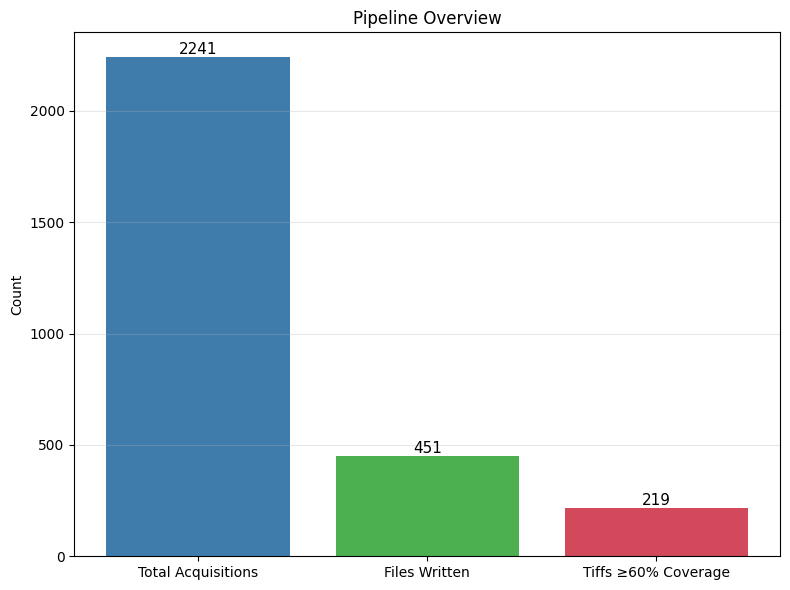

Saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/01_overview.png


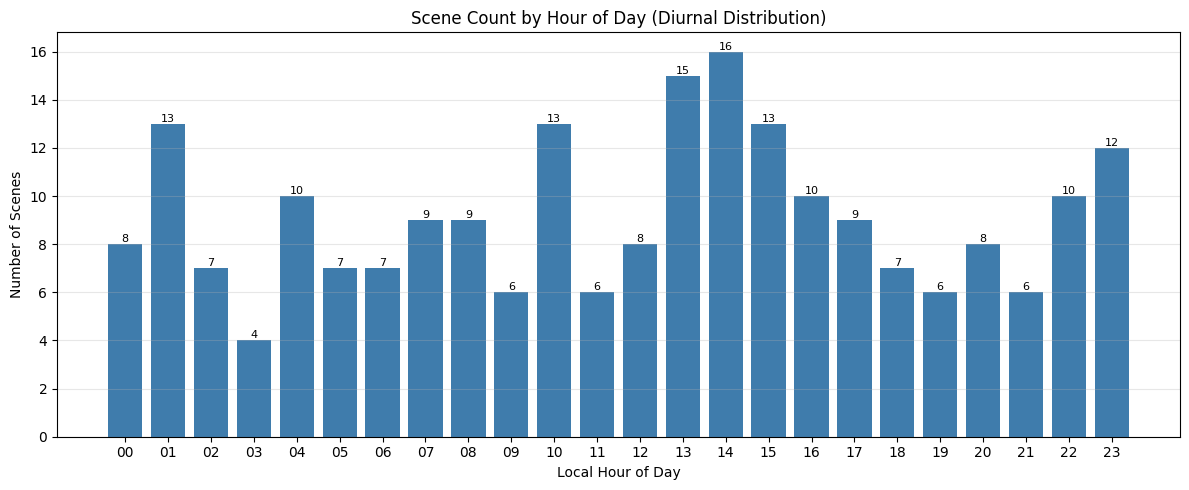

Saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/02_scene_count_by_hour.png


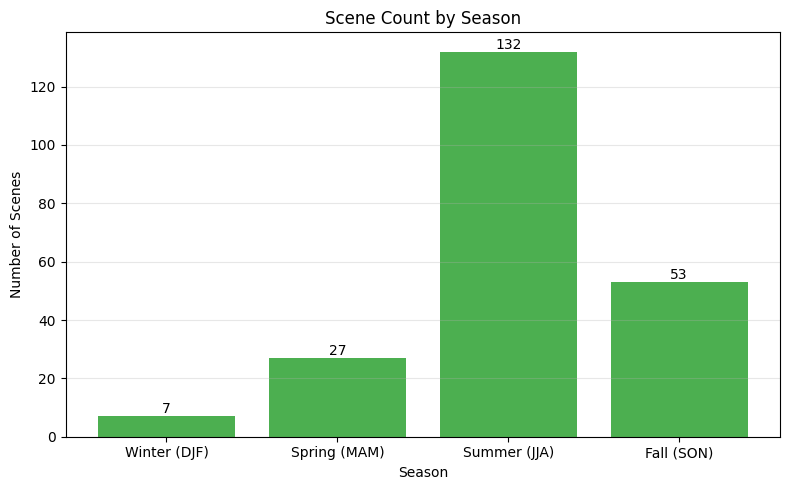

Saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/03_scene_count_by_season.png


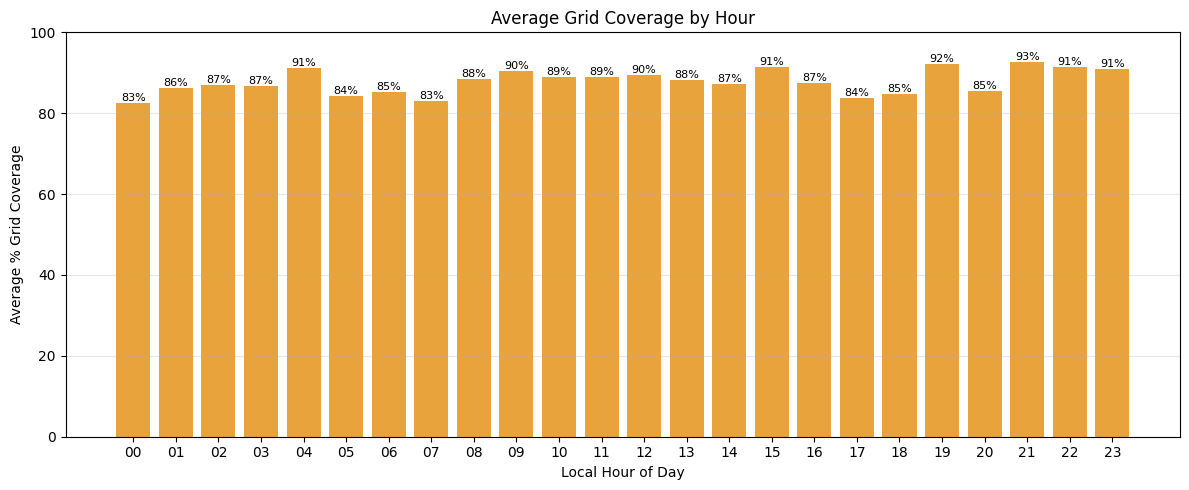

Saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/04_avg_coverage_by_hour.png


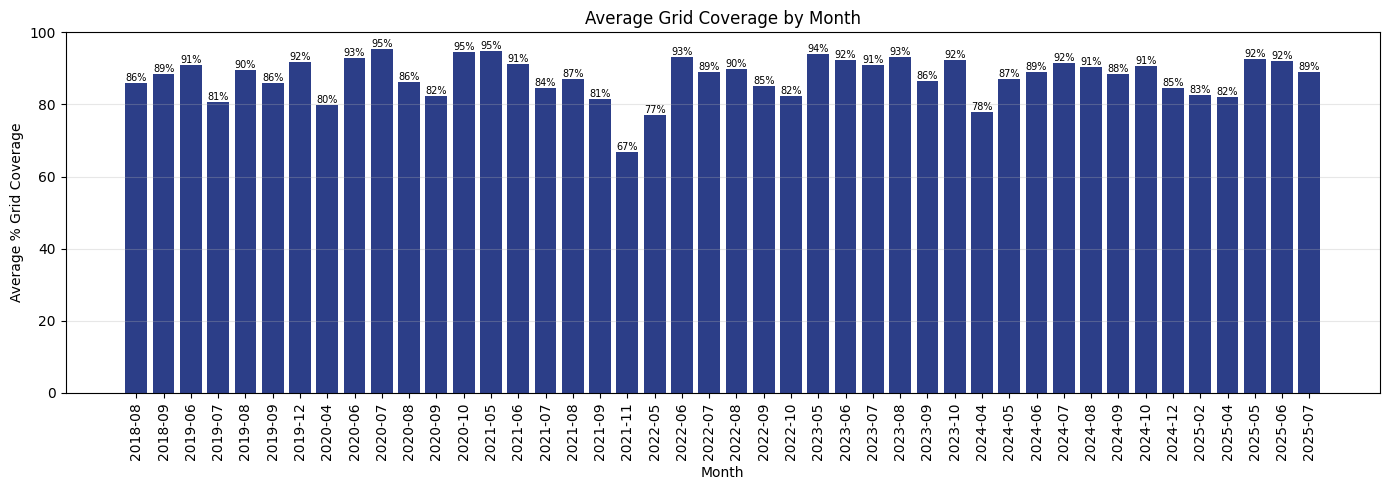

Saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/05_avg_coverage_by_month.png


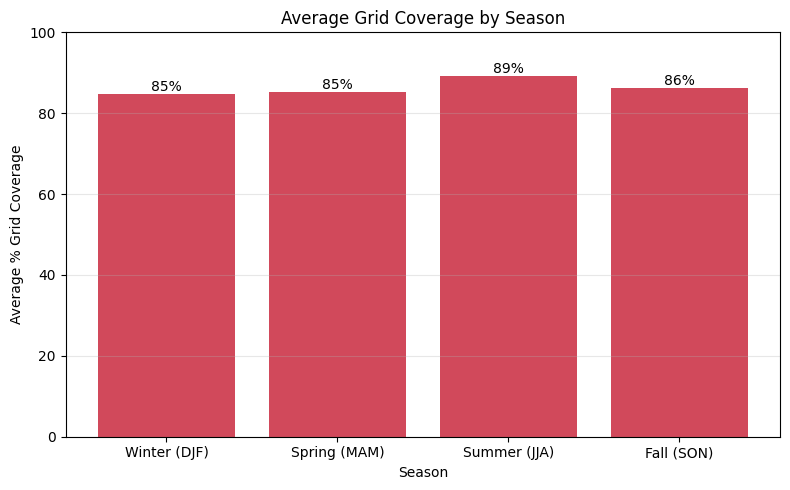

Saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/06_avg_coverage_by_season.png
Loading grid coverage matrix -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/masked_tiff/grid_coverage_matrix.csv
  Parsed + averaged 400 tiff column(s) across 647681 grid cells in 78.72s
  Rasterized grid geometry (1002x1369) in 20.74s


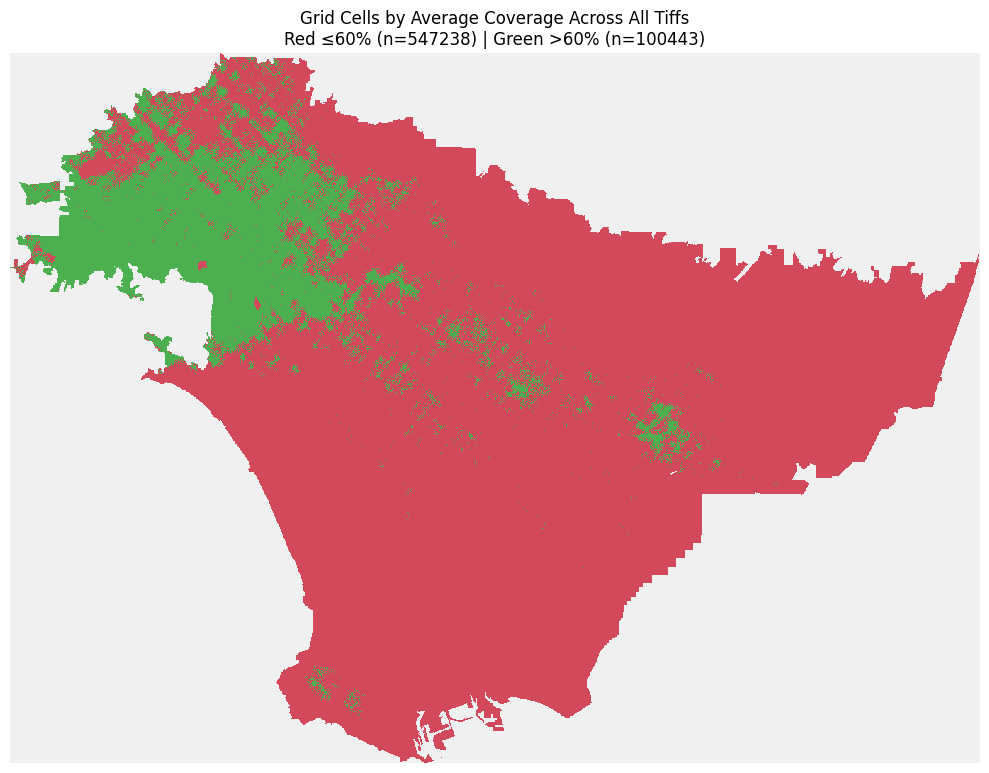

Saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/07_spatial_coverage_map.png

Step 6 summary stats saved -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary/step6_summary_stats.json
All charts saved in -> /Users/ks/Desktop/Wu/Summer26/02_SOLA_2018_2025/summary


In [8]:

import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
from datetime import datetime
from zoneinfo import ZoneInfo
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.features import rasterize
from rasterio.transform import from_origin


## Load config + Step 2 + Step 5 manifests

CONFIG_PATH = "config.json"

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

out_cfg = config["output"]
temporal_cfg = config["temporal_organization"]
grid_cfg = config["grid_coverage"]

SEASON_MONTHS = temporal_cfg["season_months"]
SEASON_ORDER = list(SEASON_MONTHS.keys())

GRID_CELL_SIZE_M = grid_cfg["grid_cell_size_m"]
GRID_ID_FIELD = grid_cfg["grid_id_field"]
CLIP_GRID = grid_cfg["clip_grid_to_boundary"]
BOUNDARY = grid_cfg["study_region_shapefile"]
EXISTING_GRID = grid_cfg.get("existing_grid_shapefile")
COVERAGE_THRESHOLD = grid_cfg["coverage_threshold"]

input_folder = config["input_folder"]
root_dir = out_cfg.get("root_dir") or os.path.dirname(os.path.normpath(input_folder))
masked_tiff_dir = os.path.join(root_dir, out_cfg.get("masked_tiff_dirname", "masked_tiff"))
summary_dir = os.path.join(root_dir, out_cfg.get("summary_dirname", "summary"))
os.makedirs(summary_dir, exist_ok=True)

step2_manifest_path = os.path.join(masked_tiff_dir, "step2_masking_manifest.json")
step5_manifest_path = os.path.join(masked_tiff_dir, "step5_grid_coverage_manifest.json")
grid_coverage_csv_path = os.path.join(masked_tiff_dir, "grid_coverage_matrix.csv")

with open(step2_manifest_path, "r") as f:
    step2_manifest = json.load(f)

with open(step5_manifest_path, "r") as f:
    step5_manifest = json.load(f)

HOUR_LABELS = [f"{h:02d}" for h in range(24)]

print(f"Loaded Step 2 manifest -> {step2_manifest_path}")
print(f"Loaded Step 5 manifest -> {step5_manifest_path}")


## Flatten Step 5's hour-bin structure into a single DataFrame

def build_coverage_dataframe(step5_manifest):
    rows = []
    for h in HOUR_LABELS:
        for entry in step5_manifest["hour_bins"].get(h, []):
            dt_local = datetime.fromisoformat(entry["datetime_local"])
            rows.append({
                "hour": h,
                "month": dt_local.strftime("%Y-%m"),
                "season": entry.get("season", "Unknown"),
                "is_merged": entry.get("is_merged", False),
                "pct_covered": entry.get("pct_covered", np.nan),
                "meets_coverage_threshold": entry.get("meets_coverage_threshold", False),
                "tiff_path": entry.get("tiff_path"),
            })
    return pd.DataFrame(rows)


coverage_df = build_coverage_dataframe(step5_manifest)
print(f"Total tiffs in Step 5 manifest: {len(coverage_df)}")
coverage_df.head()


## Chart 1 — Overview: total acquisitions / files written / tiffs >=50% coverage

def plot_overview_bar(step2_manifest, coverage_df, threshold, out_dir):
    total_acquisitions = step2_manifest["n_acquisitions_scanned"]
    files_written = step2_manifest["n_files_written"]
    n_passing_coverage = int(coverage_df["meets_coverage_threshold"].sum())

    labels = ["Total Acquisitions", "Files Written", f"Tiffs \u2265{int(threshold*100)}% Coverage"]
    values = [total_acquisitions, files_written, n_passing_coverage]
    colors = ["#3f7cac", "#4caf50", "#d1495b"]

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(labels, values, color=colors)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(v),
                 ha="center", va="bottom", fontsize=11)

    ax.set_title("Pipeline Overview")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(out_dir, "01_overview.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    return {
        "total_acquisitions": total_acquisitions,
        "files_written": files_written,
        "n_passing_coverage": n_passing_coverage,
    }


overview_stats = plot_overview_bar(step2_manifest, coverage_df, COVERAGE_THRESHOLD, summary_dir)


## Chart 2 — Scene count by hour (diurnal distribution)

def plot_scene_count_by_hour(coverage_df, out_dir):
    counts = coverage_df.groupby("hour").size().reindex(HOUR_LABELS, fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(counts.index, counts.values, color="#3f7cac")
    for bar, v in zip(bars, counts.values):
        if v:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(v)),
                     ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Local Hour of Day")
    ax.set_ylabel("Number of Scenes")
    ax.set_title("Scene Count by Hour of Day (Diurnal Distribution)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(out_dir, "02_scene_count_by_hour.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    return counts.to_dict()


hour_counts = plot_scene_count_by_hour(coverage_df, summary_dir)


## Chart 3 — Scene count by season

def plot_scene_count_by_season(coverage_df, season_order, out_dir):
    counts = coverage_df.groupby("season").size().reindex(season_order, fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(counts.index, counts.values, color="#4caf50")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(v)),
                 ha="center", va="bottom", fontsize=10)

    ax.set_xlabel("Season")
    ax.set_ylabel("Number of Scenes")
    ax.set_title("Scene Count by Season")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(out_dir, "03_scene_count_by_season.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    return counts.to_dict()


season_counts = plot_scene_count_by_season(coverage_df, SEASON_ORDER, summary_dir)


## Chart 4 — Average grid coverage by hour

def plot_avg_coverage_by_hour(coverage_df, out_dir):
    avg_cov = coverage_df.groupby("hour")["pct_covered"].mean().reindex(HOUR_LABELS)

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(avg_cov.index, avg_cov.values, color="#e8a33d")
    for bar, v in zip(bars, avg_cov.values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:.0f}%",
                     ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Local Hour of Day")
    ax.set_ylabel("Average % Grid Coverage")
    ax.set_title("Average Grid Coverage by Hour")
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(out_dir, "04_avg_coverage_by_hour.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    return avg_cov.to_dict()


avg_coverage_by_hour = plot_avg_coverage_by_hour(coverage_df, summary_dir)


## Chart 5 — Average grid coverage by month

def plot_avg_coverage_by_month(coverage_df, out_dir):
    avg_cov = coverage_df.groupby("month")["pct_covered"].mean().sort_index()

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(avg_cov.index, avg_cov.values, color="#2c3e88")
    for bar, v in zip(bars, avg_cov.values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:.0f}%",
                     ha="center", va="bottom", fontsize=7)

    ax.set_xlabel("Month")
    ax.set_ylabel("Average % Grid Coverage")
    ax.set_title("Average Grid Coverage by Month")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=90)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(out_dir, "05_avg_coverage_by_month.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    return avg_cov.to_dict()


avg_coverage_by_month = plot_avg_coverage_by_month(coverage_df, summary_dir)


## Chart 6 — Average grid coverage by season

def plot_avg_coverage_by_season(coverage_df, season_order, out_dir):
    avg_cov = coverage_df.groupby("season")["pct_covered"].mean().reindex(season_order)

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(avg_cov.index, avg_cov.values, color="#d1495b")
    for bar, v in zip(bars, avg_cov.values):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{v:.0f}%",
                     ha="center", va="bottom", fontsize=10)

    ax.set_xlabel("Season")
    ax.set_ylabel("Average % Grid Coverage")
    ax.set_title("Average Grid Coverage by Season")
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()

    out_path = os.path.join(out_dir, "06_avg_coverage_by_season.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    return avg_cov.to_dict()


avg_coverage_by_season = plot_avg_coverage_by_season(coverage_df, SEASON_ORDER, summary_dir)


## Chart 7 — Spatial map: grid cells with average coverage <=50% (red) vs >50% (green)
#
# Reads grid_coverage_matrix.csv (grid_id rows x tiff_id columns, values like "45.32%"),
# averages each row across all tiffs, then rasterizes the grid geometry once and
# renders a red/green image via imshow -- avoids GeoPandas' per-polygon .plot(),
# which is far too slow at ~650K cells (see earlier plotting bottleneck discussion).

def load_grid_for_map():
    """Loads the same grid used in Step 5A, so grid_id values line up with the CSV."""
    if EXISTING_GRID and os.path.isfile(EXISTING_GRID):
        return gpd.read_file(EXISTING_GRID)

    # fallback: rebuild identically to Step 5A's build_grid(), only if no existing grid was saved
    gdf = gpd.read_file(BOUNDARY)
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(gdf.estimate_utm_crs())

    boundary = gdf.geometry.union_all()
    minx, miny, maxx, maxy = boundary.bounds

    xs = np.arange(minx, maxx + GRID_CELL_SIZE_M, GRID_CELL_SIZE_M)
    ys = np.arange(miny, maxy + GRID_CELL_SIZE_M, GRID_CELL_SIZE_M)
    xx, yy = np.meshgrid(xs[:-1], ys[:-1])

    cells = shapely.box(xx.ravel(), yy.ravel(), xx.ravel() + GRID_CELL_SIZE_M, yy.ravel() + GRID_CELL_SIZE_M)
    cells = cells[shapely.intersects(cells, boundary)]

    if CLIP_GRID:
        cells = shapely.intersection(cells, boundary)
        cells = cells[~shapely.is_empty(cells)]

    return gpd.GeoDataFrame({GRID_ID_FIELD: range(1, len(cells) + 1)}, geometry=cells, crs=gdf.crs)


def plot_spatial_coverage_map(grid_coverage_csv_path, threshold, out_dir, max_dim=1600):
    if not os.path.isfile(grid_coverage_csv_path):
        print(f"WARNING: grid coverage CSV not found at {grid_coverage_csv_path} -- skipping spatial map.")
        return None

    print(f"Loading grid coverage matrix -> {grid_coverage_csv_path}")
    t0 = datetime.now()
    cov_df = pd.read_csv(grid_coverage_csv_path, index_col="grid_id")

    # values are strings like "45.32%" -- strip "%" and convert to float
    cov_numeric = cov_df.apply(lambda col: col.astype(str).str.rstrip("%").astype(float))
    avg_coverage = cov_numeric.mean(axis=1)  # average across all tiffs, per grid cell
    t1 = datetime.now()
    print(f"  Parsed + averaged {len(cov_df.columns)} tiff column(s) across {len(cov_df)} grid cells in {(t1-t0).total_seconds():.2f}s")

    grid = load_grid_for_map()
    grid = grid.set_index(GRID_ID_FIELD)

    # align on grid_id -- any grid cell missing from the CSV (e.g. zero tiffs touched it) is treated as 0% coverage
    avg_coverage = avg_coverage.reindex(grid.index).fillna(0.0)

    # rasterize grid geometry once (grid_id -> pixel), same approach as Step 5A's grid_ids raster
    minx, miny, maxx, maxy = grid.total_bounds
    width = int(np.ceil((maxx - minx) / GRID_CELL_SIZE_M))
    height = int(np.ceil((maxy - miny) / GRID_CELL_SIZE_M))
    transform = from_origin(minx, maxy, GRID_CELL_SIZE_M, GRID_CELL_SIZE_M)

    t2 = datetime.now()
    shapes = ((geom, i + 1) for i, geom in enumerate(grid.geometry))
    grid_id_raster = rasterize(shapes, out_shape=(height, width), transform=transform, fill=0, dtype="int32")
    t3 = datetime.now()
    print(f"  Rasterized grid geometry ({height}x{width}) in {(t3-t2).total_seconds():.2f}s")

    # build a lookup: pixel index (0..N) -> 0=below threshold(red)/no-data, 1=above threshold(green)
    # index 0 (no grid cell / outside boundary) stays "no data" and is masked transparent
    n_cells = len(grid)
    class_lookup = np.zeros(n_cells + 1, dtype="int8")   # default 0 = red / no-data
    class_lookup[1:] = np.where(avg_coverage.values > threshold * 100, 2, 1)  # 1=red(<=thresh), 2=green(>thresh)

    class_img = class_lookup[grid_id_raster]  # 0=no data, 1=red, 2=green

    # downsample for a reasonably sized PNG
    if max(class_img.shape) > max_dim:
        step = int(np.ceil(max(class_img.shape) / max_dim))
        class_img = class_img[::step, ::step]

    # 0 -> white/transparent (no data), 1 -> red, 2 -> green
    cmap = ListedColormap(["#f0f0f0", "#d1495b", "#4caf50"])

    n_red = int((avg_coverage <= threshold * 100).sum())
    n_green = int((avg_coverage > threshold * 100).sum())

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(class_img, cmap=cmap, vmin=0, vmax=2, interpolation="nearest")
    ax.set_title(
        f"Grid Cells by Average Coverage Across All Tiffs\n"
        f"Red \u2264{int(threshold*100)}% (n={n_red}) | Green >{int(threshold*100)}% (n={n_green})"
    )
    ax.axis("off")
    plt.tight_layout()

    out_path = os.path.join(out_dir, "07_spatial_coverage_map.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_path}")

    return {
        "n_cells_low_coverage": n_red,
        "n_cells_high_coverage": n_green,
        "pct_cells_low_coverage": 100 * n_red / n_cells if n_cells else 0,
    }


spatial_coverage_stats = plot_spatial_coverage_map(grid_coverage_csv_path, COVERAGE_THRESHOLD, summary_dir)


## Write Step 6 summary stats JSON

summary_stats = {
    "step": "step6_summary_plots",
    "generated_at": datetime.now(ZoneInfo("UTC")).isoformat(),
    "summary_dir": summary_dir,
    "coverage_threshold": COVERAGE_THRESHOLD,
    "overview": overview_stats,
    "scene_count_by_hour": hour_counts,
    "scene_count_by_season": season_counts,
    "avg_coverage_pct_by_hour": avg_coverage_by_hour,
    "avg_coverage_pct_by_month": avg_coverage_by_month,
    "avg_coverage_pct_by_season": avg_coverage_by_season,
    "spatial_coverage_map": spatial_coverage_stats,
}

step6_summary_path = os.path.join(summary_dir, "step6_summary_stats.json")

with open(step6_summary_path, "w") as f:
    json.dump(summary_stats, f, indent=2, default=str)

print(f"\nStep 6 summary stats saved -> {step6_summary_path}")
print(f"All charts saved in -> {summary_dir}")

In [ ]:
print('Done')

## Next Step: 02_Ecostress_Zonal_Stats